In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/val/healthy_guava/72_unsharp_clahe_augmented_6.png
/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/val/healthy_guava/49_unsharp_clahe_augmented_1.png
/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/val/healthy_guava/57_unsharp_clahe_augmented_1.png
/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/val/healthy_guava/97_unsharp_clahe_augmented_3.png
/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/val/healthy_guava/60_unsharp_clahe_augmented_4.png
/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/val/healthy_guava/100_unsharp_clahe_augmented_3.png
/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/val/healthy_guava/26_unsharp_clahe_augmented_1.png
/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/val/healthy_guava/74_unsharp_clahe_augmented_0.png
/kaggle/input/datasets/

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import time
import os
import copy
import matplotlib.pyplot as plt

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [12]:
data_dir = '/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset'

train_dir = os.path.join(data_dir, '/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/train')
val_dir = os.path.join(data_dir, '/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/val')
test_dir = os.path.join(data_dir, '/kaggle/input/datasets/abid074/guavadiseasedataset/GuavaDiseaseDataset/test')

In [14]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize(300),
        transforms.RandomResizedCrop(299),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(300),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(300),
        transforms.CenterCrop(299),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [15]:
image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'val': datasets.ImageFolder(val_dir, data_transforms['val']),
    'test': datasets.ImageFolder(test_dir, data_transforms['test'])
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=4)
    for x in ['train', 'val', 'test']
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

print(f"Classes: {class_names}")
print(f"Training images: {dataset_sizes['train']}")

Classes: ['Anthracnose', 'fruit_fly', 'healthy_guava']
Training images: 2647


In [16]:
model = models.inception_v3(weights='DEFAULT')

# Handle the Auxiliary net
num_ftrs_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(num_ftrs_aux, 3)

# Handle the primary net
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 3)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 190MB/s] 


In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [18]:
def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    # InceptionV3 returns (output, aux_output) during training
                    if phase == 'train':
                        outputs, aux_outputs = model(inputs)
                        loss1 = criterion(outputs, labels)
                        loss2 = criterion(aux_outputs, labels)
                        loss = loss1 + 0.4 * loss2 # Standard weighting for Inception
                    else:
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    return model, history

model, history = train_model(model, criterion, optimizer, num_epochs=10)

Epoch 1/10
----------
train Loss: 0.5464 Acc: 0.8644
val Loss: 1.2271 Acc: 0.6570
Epoch 2/10
----------
train Loss: 0.3123 Acc: 0.9252
val Loss: 0.0929 Acc: 0.9709
Epoch 3/10
----------
train Loss: 0.2801 Acc: 0.9324
val Loss: 0.1598 Acc: 0.9457
Epoch 4/10
----------
train Loss: 0.2318 Acc: 0.9422
val Loss: 0.0425 Acc: 0.9828
Epoch 5/10
----------
train Loss: 0.2051 Acc: 0.9532
val Loss: 0.0871 Acc: 0.9735
Epoch 6/10
----------
train Loss: 0.1663 Acc: 0.9569
val Loss: 0.0472 Acc: 0.9841
Epoch 7/10
----------
train Loss: 0.1767 Acc: 0.9566
val Loss: 0.1968 Acc: 0.9192
Epoch 8/10
----------
train Loss: 0.1682 Acc: 0.9577
val Loss: 0.0281 Acc: 0.9921
Epoch 9/10
----------
train Loss: 0.1953 Acc: 0.9501
val Loss: 0.0546 Acc: 0.9868
Epoch 10/10
----------
train Loss: 0.1462 Acc: 0.9664
val Loss: 0.0385 Acc: 0.9881
Training complete in 5m 5s


In [19]:
model.eval()
test_corrects = 0

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        test_corrects += torch.sum(preds == labels.data)

test_acc = test_corrects.double() / dataset_sizes['test']
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.9791


In [20]:
torch.save(model.state_dict(), 'guava_inception_v3.pth')
print("Model saved as guava_inception_v3.pth")

Model saved as guava_inception_v3.pth


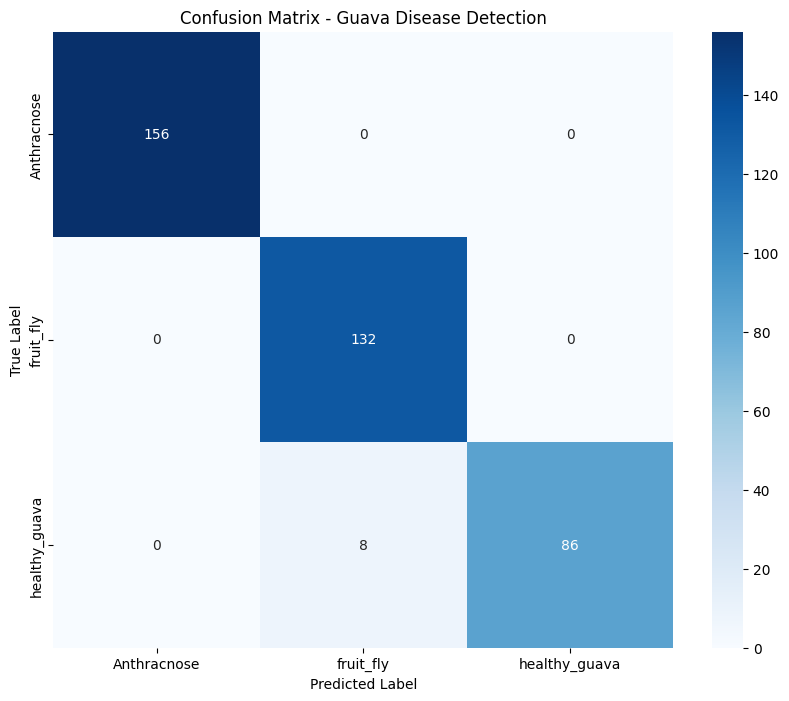

Accuracy for Anthracnose: 100.00%
Accuracy for fruit_fly: 100.00%
Accuracy for healthy_guava: 91.49%


In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np


all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


cm = confusion_matrix(all_labels, all_preds)


plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Guava Disease Detection')
plt.show()


cm_acc = cm.diagonal() / cm.sum(axis=1)
for i, class_name in enumerate(class_names):
    print(f'Accuracy for {class_name}: {cm_acc[i]*100:.2f}%')

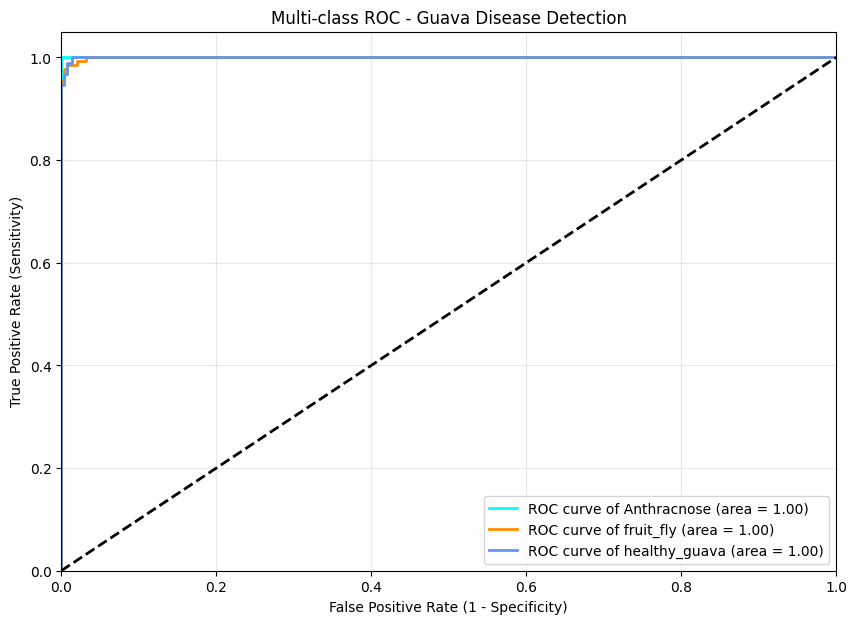

In [24]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from itertools import cycle


all_probs = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        
        outputs = model(inputs)
        
        probs = torch.nn.functional.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

n_classes = len(class_names)
binarized_labels = label_binarize(all_labels, classes=[0, 1, 2])


fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(binarized_labels[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


plt.figure(figsize=(10, 7))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of {class_names[i]} (area = {roc_auc[i]:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Multi-class ROC - Guava Disease Detection')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()